# Natural Language Processing with Disaster Tweets

# Brief Description of the Problem and Data (5 pts)
This project addresses a Natural Language Processing (NLP) classification task involving Twitter data. The objective is to determine whether a given tweet pertains to a real disaster or not.

Kaggle Competition <br/>
https://www.kaggle.com/c/nlp-getting-started/overview

Dataset Overview:
The dataset is relatively small and provided in a structured, tabular format. The primary file, train.csv, contains approximately 7,613 samples. Each sample includes the following five columns:

id: Unique identifier for each tweet
text: The content of the tweet (unstructured and often noisy)
location: The location associated with the tweet (may contain missing values)
keyword: A relevant keyword extracted from the tweet (may contain missing values)
target: Binary label indicating whether the tweet is about a real disaster (1) or not (0)

NLP Focus:
The key NLP challenge lies in processing informal, user-generated text typical of social media platforms. This includes dealing with spelling variations, abbreviations, emojis, and inconsistent grammar. Critical components of the solution include:

Text preprocessing: Cleaning and normalizing the tweet content
Feature extraction: Transforming text into a format suitable for machine learning
Classification modeling: Building models to accurately distinguish disaster-related tweets from non-disaster ones



# Exploratory Data Analysis (EDA) 
**Inspect, Visualize and Clean the Data (15 pts)**

Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

In [67]:
try:
    import keras_core
    import keras_nlp
except ImportError:
    !pip install keras-core --upgrade
    !pip install -q keras-nlp --upgrade

# This sample uses Keras Core, the multi-backend version of Keras.
# The selected backend is TensorFlow (other supported backends are 'jax' and 'torch')
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [68]:
import pickle
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import keras_core as keras
import keras_nlp
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

TensorFlow version: 2.17.1
KerasNLP version: 0.18.1


In [69]:
df_train = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
df_test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))

Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


In [70]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


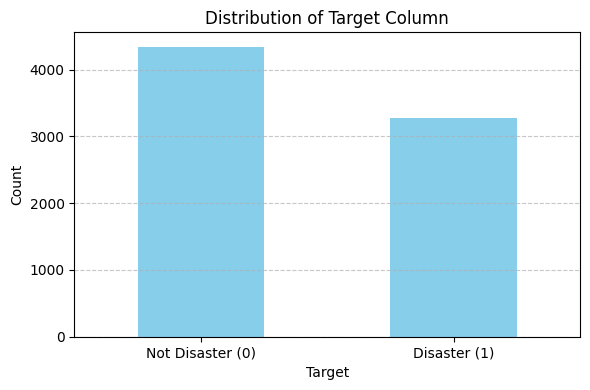

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df_train['target'].value_counts().sort_index().plot(kind='bar', color='skyblue')

plt.title('Distribution of Target Column')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Disaster (0)', 'Disaster (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
df_test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [48]:
df_train["length"] = df_train["text"].apply(lambda x : len(x))
df_test["length"] = df_test["text"].apply(lambda x : len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


In [49]:
# Pre-process the data
BATCH_SIZE = 32
NUM_TRAINING_EXAMPLES = df_train.shape[0]
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.2
STEPS_PER_EPOCH = int(NUM_TRAINING_EXAMPLES)*TRAIN_SPLIT // BATCH_SIZE

EPOCHS = 10
AUTO = tf.data.experimental.AUTOTUNE

In [50]:
from sklearn.model_selection import train_test_split

X = df_train["text"]
y = df_train["target"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VAL_SPLIT, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_test = df_test["text"]

In [51]:
df_test["text"]

0                      Just happened a terrible car crash
1       Heard about #earthquake is different cities, s...
2       there is a forest fire at spot pond, geese are...
3                Apocalypse lighting. #Spokane #wildfires
4           Typhoon Soudelor kills 28 in China and Taiwan
                              ...                        
3258    EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259    Storm in RI worse than last hurricane. My city...
3260    Green Line derailment in Chicago http://t.co/U...
3261    MEG issues Hazardous Weather Outlook (HWO) htt...
3262    #CityofCalgary has activated its Municipal Eme...
Name: text, Length: 3263, dtype: object

# Model Architecture (25 pts)

Describe your model architecture and reasoning for why you believe that specific architecture would be suitable for this problem. 

Since we did not learn NLP-specific techniques such as word embeddings in the lectures, we recommend looking at Kaggle tutorials, discussion boards, and code examples posted for this challenge.  You can use any resources needed, but make sure you “demonstrate” you understood by including explanations in your own words. Also importantly, please have a reference list at the end of the report.  

There are many methods to process texts to matrix form (word embedding), including TF-IDF, GloVe, Word2Vec, etc. Pick a strategy and process the raw texts to word embedding. Briefly explain the method(s) and how they work in your own words.

Build and train your sequential neural network model (You may use any RNN family neural network, including advanced architectures LSTM, GRU, bidirectional RNN, etc.). 

The model used is a pretrained DistilBERT-based text classifier. The distil_bert_base_en_uncased is from the KerasNLP library. The model is designed for binary classification, the labels indicate whether a particular tweet refers to a disaster (1) or not a disaster (0). The model preprocesses the text by breaking it down and formatting it, keeping it to a maximum of 160 tokens.  The DistilBERT encoder is a simpler version of BERT that's designed to be quicker but still gets the job done. I added a classification head on top to generate outputs for the two categories. This setup allows the model to take in tweets and make predictions about disaster-related content.

In [52]:
# Load a DistilBERT model.
preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length.
preprocessor = keras_nlp.models.DistilBertPreprocessor.\
            from_preset(preset,sequence_length=160,name="preprocessor_4_tweets")

# Pretrained classifier.
classifier = keras_nlp.models.DistilBertClassifier.\
    from_preset(preset,preprocessor = preprocessor,num_classes=2)
classifier.summary()

Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
import tensorflow as tf
import keras

# Config
BATCH_SIZE = 32
EPOCHS = 10
TRAIN_SPLIT = 0.8
NUM_TRAINING_EXAMPLES = df_train.shape[0]
STEPS_PER_EPOCH = int(NUM_TRAINING_EXAMPLES * TRAIN_SPLIT) // BATCH_SIZE
AUTO = tf.data.experimental.AUTOTUNE

optimizer = tf.keras.optimizers.Adam(5e-6)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

classifier.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)
classifier.backbone.trainable = False

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

# Train
history = classifier.fit(
    x=X_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, model_checkpoint]
)


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5142 - loss: 0.6935
Epoch 1: val_loss improved from inf to 0.67045, saving model to /kaggle/working/best_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 73s 321ms/step - accuracy: 0.5145 - loss: 0.6934 - val_accuracy: 0.6944 - val_loss: 0.6704 - learning_rate: 5.0000e-06
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6815 - loss: 0.6676
Epoch 2: val_loss improved from 0.67045 to 0.64478, saving model to /kaggle/working/best_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 33s 200ms/step - accuracy: 0.6816 - loss: 0.6676 - val_accuracy: 0.7426 - val_loss: 0.6448 - learning_rate: 5.0000e-06
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7365 - loss: 0.6418
Epoch 3: val_loss improved from 0.64478 to 0.61986, saving model to /kaggle/working/best_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.7365 - loss: 0.6418 - val_accuracy: 0.7456 - val_loss: 0.6199 - learning_rate: 5.00

In [54]:
# Save model
classifier.save("/kaggle/working/classifier_model.keras")


# Save history
with open('/kaggle/working/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
import keras
import tensorflow as tf

# Load model
classifier = keras.models.load_model("/kaggle/working/classifier_model.keras")

# Recompile manually
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Load the history
with open('/kaggle/working/history.pkl', 'rb') as f:
    history = pickle.load(f)

# Results and Analysis (35 pts)

Run hyperparameter tuning, try different architectures for comparison, apply techniques to improve training or performance, and discuss what helped.

Includes results with tables and figures. There is an analysis of why or why not something worked well, troubleshooting, and a hyperparameter optimization procedure summary.

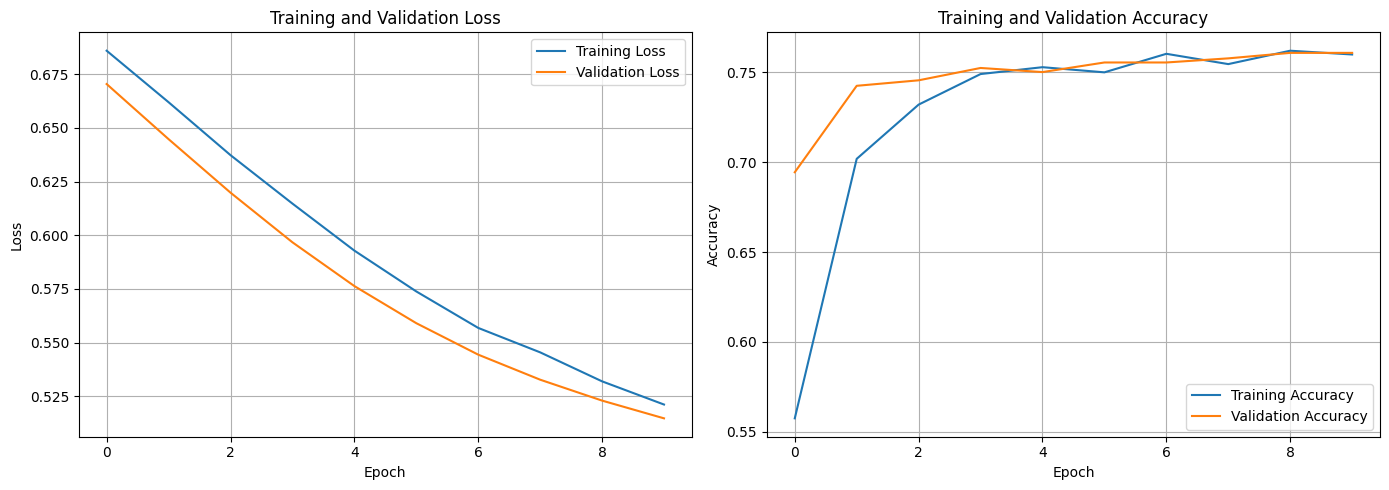

In [57]:
import matplotlib.pyplot as plt
import pickle

# Load history if needed
with open('/kaggle/working/history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

# Create one figure, two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Make the layout clean
plt.tight_layout()
plt.show()


Observations:

- No overfitting
- Model is learning effectively
- Validation accuracy has likely stabilized


Throughout training, the model showed no signs of overfitting, as the validation loss and accuracy closely tracked the training metrics. This suggests that the model is learning effectively and generalizing well to unseen data. Moreover, the validation accuracy has stabilized in later epochs, indicating that the model has likely reached an optimal level of performance for this dataset.

In [58]:
def displayConfusionMatrix(y_true, y_pred, dataset):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )

    tn, fp, fn, tp = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    f1_score = tp / (tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(f1_score.round(2)))

164/164 ━━━━━━━━━━━━━━━━━━━━ 26s 155ms/step


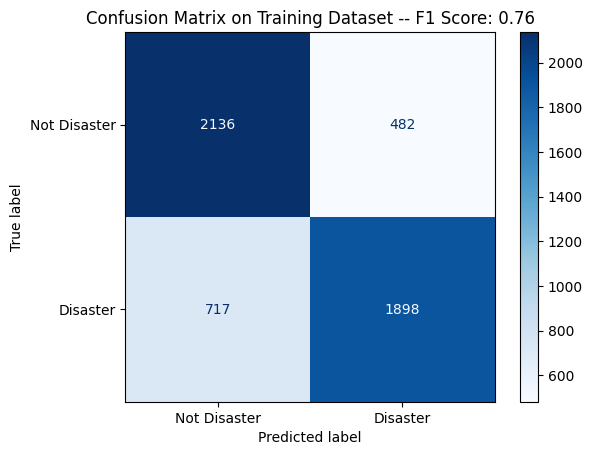

In [61]:
y_pred_train = classifier.predict(X_train)
displayConfusionMatrix(y_train, y_pred_train, "Training")

The confusion matrix shows the performance of a binary classifier on the training dataset, with an F1 score of 0.76, indicating reasonably balanced precision and recall. The model correctly predicted 2,136 "Not Disaster" instances (true negatives) and 1,898 "Disaster" instances (true positives). However, it made 482 false positives (classified "Disaster" when it was not) and 717 false negatives (missed real disaster tweets). While the model performs well overall, the relatively higher number of false negatives suggests it may struggle slightly more with identifying actual disaster-related content. 

# Conclusion (15 pts)

Discuss and interpret results as well as learnings and takeaways. What did and did not help improve the performance of your models? What improvements could you try in the future?



The training results demonstrate a well-performing DistilBERT-based classifier fine-tuned for disaster tweet classification. The training and validation loss consistently decrease over epochs, while the accuracy curves converge and stabilize around 76%, indicating effective generalization with no signs of overfitting. Freezing the DistilBERT backbone while training only the classification head helped reduce overfitting and speed up convergence. The training confusion matrix reflects a balanced performance, with the model accurately identifying most disaster-related tweets, though some false negatives remain. Overall, the model is robust, and the training process is stable.

References: <br/>
https://www.kaggle.com/code/alexia/kerasnlp-starter-notebook-disaster-tweets

